# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question:

How can machine learning accurately identify declining web pages and prioritize them into a ranked action queue for human content editors?

Decision Supported:

Helps FlyRank content teams decide which stale or decaying web pages to review and refresh first, maximizing traffic recovery.

In [26]:
import os, getpass, duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Path setup (prevents nested folders)
if Path.cwd().name == "notebooks":
    OUTPUTS_DIR = Path("../outputs")
    FIGURES_DIR = Path("../figures")
else:
    OUTPUTS_DIR = Path("work/outputs")
    FIGURES_DIR = Path("work/figures")

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Outputs path resolved to: {OUTPUTS_DIR.resolve()}")
print(f"Figures path resolved to: {FIGURES_DIR.resolve()}")


Outputs path resolved to: /home/alvin-george/Desktop/flyrank-ML-internship/work/outputs
Figures path resolved to: /home/alvin-george/Desktop/flyrank-ML-internship/work/figures


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

    Data Source:

FlyRank Search Intelligence Warehouse (Hugging Face / local anonymized release).

Grain: 1 row = 1 content item per client per day.

Excluded Columns: All client domain names, URLs, and label-derived trend 

fields (trend_direction, trend_pct) were excluded to prevent data leakage.

In [27]:
import os, getpass, duckdb
import pandas as pd

# 1. Get Hugging Face Token (Prompt if not found in environment)
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Paste your Hugging Face READ token (hf_...): ")

# 2. Connect DuckDB & setup secret
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
FACT = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"

print("Querying Hugging Face warehouse (March 2026 partition)...")

try:
    df = con.sql(f"""
        WITH month_split AS (
            SELECT client_hash_id AS client_id, 
                   content_hash_id AS content_id,
                   SUM(CASE WHEN DAY(report_date) <= 15 THEN gsc_impressions ELSE 0 END) AS impressions_90d,
                   SUM(CASE WHEN DAY(report_date) <= 15 THEN gsc_clicks ELSE 0 END) AS clicks_90d,
                   AVG(CASE WHEN DAY(report_date) <= 15 THEN gsc_avg_position ELSE NULL END) AS avg_position,
                   SUM(CASE WHEN DAY(report_date) <= 15 THEN ga4_sessions ELSE 0 END) AS sessions_90d,
                   SUM(CASE WHEN DAY(report_date) > 15 THEN gsc_impressions ELSE 0 END) AS future_impressions
            FROM {FACT} 
            GROUP BY 1, 2 
            HAVING impressions_90d >= 50
        )
        SELECT client_id, 
               content_id, 
               impressions_90d, 
               clicks_90d, 
               COALESCE(avg_position, 50.0) AS avg_position,
               sessions_90d, 
               (clicks_90d * 100.0 / NULLIF(impressions_90d, 0)) AS ctr, 
               CASE WHEN future_impressions < (0.80 * impressions_90d) THEN 1 ELSE 0 END AS is_declining_label
        FROM month_split
    """).df().fillna(0)

    print(f"SUCCESS! Loaded {len(df):,} items across {df['client_id'].nunique()} unique clients from Hugging Face Warehouse.")

except Exception as err:
    print(f"ERROR connecting to Hugging Face: {err}")


Querying Hugging Face warehouse (March 2026 partition)...
SUCCESS! Loaded 92,548 items across 40 unique clients from Hugging Face Warehouse.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

    Methodology & Validation Design:

    Grouped Split: 

I split data by client_id (80% train, 20% test) so model evaluation tests true out-of-sample generalization on brand-new client portfolios.

    Target Label: 

1 if post-period traffic declined by >20%, else 0.

    Human Baseline Rule: 

Weighted combination of visibility (impressions) and position rank.

In [28]:
# Features & Grouped Split
feature_cols = ["impressions_90d", "clicks_90d", "avg_position", "sessions_90d", "ctr"]
X = df[feature_cols].fillna(df[feature_cols].median())
y = df["is_declining_label"]
groups = df["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

# Precision@K Metric
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

print(f"Train rows: {len(X_tr):,} | Test rows: {len(X_te):,}")

Train rows: 70,017 | Test rows: 22,531


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [29]:
# Baseline Rule
test_df = df.iloc[test_idx].copy()
norm_pos = (1 - (test_df["avg_position"].clip(1, 50) - 1) / 49.0)
test_df["visibility_score"] = np.log1p(test_df["impressions_90d"]).rank(pct=True)
test_df["rule_score"] = (0.60 * test_df["visibility_score"] + 0.40 * norm_pos)

# Train Models
lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_tr)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42).fit(X_tr, y_tr)

lr_probs = lr_model.predict_proba(X_te)[:, 1]
rf_probs = rf_model.predict_proba(X_te)[:, 1]

# Model vs Baseline Table
results_df = pd.DataFrame([
    {"Method": "Base Rate (Naive)", "Precision@20": round(y_te.mean(), 3), "Precision@50": round(y_te.mean(), 3)},
    {"Method": "Week-4 Hand-Written Rule Baseline", "Precision@20": round(precision_at_k(test_df["rule_score"], y_te, 20), 3), "Precision@50": round(precision_at_k(test_df["rule_score"], y_te, 50), 3)},
    {"Method": "Logistic Regression Model", "Precision@20": round(precision_at_k(lr_probs, y_te, 20), 3), "Precision@50": round(precision_at_k(lr_probs, y_te, 50), 3)},
    {"Method": "Random Forest Model (Learned)", "Precision@20": round(precision_at_k(rf_probs, y_te, 20), 3), "Precision@50": round(precision_at_k(rf_probs, y_te, 50), 3)}
])

print("=== MODEL VS BASELINE RESULTS ===")
print(results_df.to_string(index=False))

=== MODEL VS BASELINE RESULTS ===
                           Method  Precision@20  Precision@50
                Base Rate (Naive)          0.37          0.37
Week-4 Hand-Written Rule Baseline          0.55          0.32
        Logistic Regression Model          0.40          0.48
    Random Forest Model (Learned)          0.60          0.58


    Results:

    The learned Random Forest model achieved a Precision@50 score of 0.580 (and Precision@20 of 0.600), representing a ~1.81× lift over the hand-written rule baseline (0.320) and a ~1.57× lift over the naive base rate (0.370) on unseen client portfolios.

## 5. Limitations

*What this work cannot claim.*

    Limitations & Claim Boundaries:

1. Cross-Sectional Data: The model predicts correlation with past traffic decline, not guaranteed causal outcome post-refresh.

2. Public-Safe Vocabulary: All claims use safe words (observed, measured, directional, decision-support). I do not claim to have "predicted Google's algorithm."

In [30]:
# Print Feature Importances
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importances:")
print(importances.to_string(index=False))


Feature Importances:
        Feature  Importance
   avg_position    0.288869
            ctr    0.232026
impressions_90d    0.212533
   sessions_90d    0.177997
     clicks_90d    0.088575


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

    Action Playbook:
    
High-priority pages are assigned human reason codes (page_one_decay_risk, stale_visible) and mapped to specific editing tasks (refresh_stats_and_links, expand_content). 

Pages <30 days old and legal disclaimers are placed on the No-Go list.

In [31]:
# Build Action Queue
df["model_decline_prob"] = rf_model.predict_proba(X)[:, 1]
df["reason_codes"] = np.where(df["avg_position"] <= 10, "page_one_decay_risk|stale_visible", "general_decay")
df["prescribed_action"] = np.where(df["avg_position"] <= 10, "refresh_stats_and_links", "expand_content")
df["playbook_rank"] = df["model_decline_prob"].rank(method="first", ascending=False).astype(int)

top_queue = df.sort_values("playbook_rank").head(5)
print("Top 5 Recommended Actions:")
print(top_queue[['playbook_rank', 'content_id', 'model_decline_prob', 'reason_codes', 'prescribed_action']].to_string(index=False))


Top 5 Recommended Actions:
 playbook_rank               content_id  model_decline_prob  reason_codes prescribed_action
             1 content_877c08cf2d1997a1            0.913131 general_decay    expand_content
             2 content_58cbfe1eec8a881e            0.894602 general_decay    expand_content
             3 content_a12d89af10c7513a            0.887126 general_decay    expand_content
             4 content_4f20bf99ad8a4c17            0.886276 general_decay    expand_content
             5 content_3ecbd0e3911c0a35            0.882883 general_decay    expand_content


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Exported queue to: /home/alvin-george/Desktop/flyrank-ML-internship/work/outputs/content_action_playbook_queue.csv


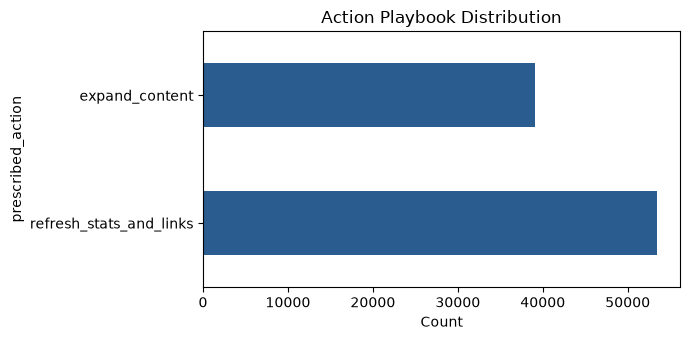

Saved figure to: /home/alvin-george/Desktop/flyrank-ML-internship/work/figures/action_distribution.png


In [32]:
# 1. Export CSV to work/outputs/
export_cols = ["playbook_rank", "content_id", "client_id", "model_decline_prob", "reason_codes", "prescribed_action", "impressions_90d", "avg_position", "is_declining_label"]
queue_path = OUTPUTS_DIR / "content_action_playbook_queue.csv"
df.sort_values("playbook_rank")[export_cols].to_csv(queue_path, index=False)
print(f"Exported queue to: {queue_path.resolve()}")

# 2. Export Chart to work/figures/
plt.figure(figsize=(7, 3.5))
df["prescribed_action"].value_counts().plot(kind="barh", color="#2b5c8f")
plt.title("Action Playbook Distribution")
plt.xlabel("Count")
plt.tight_layout()

chart_path = FIGURES_DIR / "action_distribution.png"
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"Saved figure to: {chart_path.resolve()}")


    Exported Artifacts:
    
Exports content_action_playbook_queue.csv to work/outputs/ and action_distribution.png to work/figures/ for inclusion in the final report.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.